<a href="https://colab.research.google.com/github/Upasana92b/Readme/blob/main/Desk%20Allocation-RNLI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# Load the datasets

In [3]:
desk_booking_history = pd.read_csv("/content/Desk Booking History.csv")
desks = pd.read_csv("/content/Desks.csv")

In [4]:
print("\n--- DeskBookingHistory DataFrame Info ---")
desk_booking_history.info()
print("\n--- DeskBookingHistory DataFrame Head ---")
print(desk_booking_history.head())


--- DeskBookingHistory DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      30000 non-null  object 
 1   Title        30000 non-null  object 
 2   From         30000 non-null  object 
 3   To           30000 non-null  object 
 4   User         29818 non-null  object 
 5   Unique ID    29998 non-null  float64
 6   Desk ID      14224 non-null  object 
 7   Department   29818 non-null  object 
 8   Checked in   29818 non-null  object 
 9   Date Booked  29818 non-null  object 
dtypes: float64(1), object(9)
memory usage: 2.3+ MB

--- DeskBookingHistory DataFrame Head ---
            Created Title               From                 To  \
0  5/3/2022 7:50 PM  T202  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
1  5/3/2022 8:07 PM  T258  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
2  5/3/2022 8:07 PM   F23  4/27/2022 8:00 AM  4/

In [5]:
print("\n--- Desks DataFrame Info ---")
desks.info()
print("\n--- Desks DataFrame Head ---")
print(desks.head())


--- Desks DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 436 non-null    int64 
 1   Title              436 non-null    object
 2   Department         433 non-null    object
 3   Screens            436 non-null    object
 4   Building           436 non-null    object
 5   Floor              436 non-null    object
 6   Bookable           436 non-null    bool  
 7   Accessibility      436 non-null    object
 8   Site               436 non-null    object
 9   Reason Unbookable  236 non-null    object
 10  Restricted team    3 non-null      object
dtypes: bool(1), int64(1), object(9)
memory usage: 34.6+ KB

--- Desks DataFrame Head ---
    ID Title Department Screens Building Floor  Bookable  Accessibility  \
0  383  T292     People       2      LSC     3      True  Standard desk   
1  137   F46  

In [6]:
print("\nUnique values in 'Building' column (Desks.csv):", desks["Building"].unique())
print("Unique values in 'Floor' column (Desks.csv):", desks["Floor"].unique())


Unique values in 'Building' column (Desks.csv): ['LSC']
Unique values in 'Floor' column (Desks.csv): ['3' '1' '2' 'Ground']


# Filter desks for LSC building and 3rd floor

In [7]:
lsc3_desks = desks[(desks["Building"] == "LSC") & (desks["Floor"] == "3")]

In [8]:
print(f"\nNumber of LSC3 desks found: {len(lsc3_desks)}")
print("LSC3 Desks Head:\n", lsc3_desks.head())


Number of LSC3 desks found: 293
LSC3 Desks Head:
       ID Title Department Screens Building Floor  Bookable  Accessibility  \
0    383  T292     People       2      LSC     3      True  Standard desk   
132  244   T25        NaN       2      LSC     3     False  Standard desk   
133  245   T26        NaN       2      LSC     3     False  Standard desk   
134  246   T27        NaN       2      LSC     3     False  Standard desk   
135  247   T28  CE Office       2      LSC     3      True  Standard desk   

                           Site Reason Unbookable Restricted team  
0    RNLI Support Centre, Poole               NaN             NaN  
132  RNLI Support Centre, Poole     No department             NaN  
133  RNLI Support Centre, Poole     No department             NaN  
134  RNLI Support Centre, Poole     No department             NaN  
135  RNLI Support Centre, Poole               NaN             NaN  


# Rename 'Title' column in lsc3_desks to 'DeskTitle' to avoid confusion during merge

In [9]:
lsc3_desks_renamed = lsc3_desks.rename(columns={'Title': 'DeskTitle'})

# Merge booking history with LSC3 desks to get relevant bookings

In [10]:
merged_data = pd.merge(desk_booking_history, lsc3_desks_renamed, left_on='Title', right_on='DeskTitle', how='inner')

In [11]:
print(f"\nShape of merged_data (LSC3 bookings): {merged_data.shape}")
print("Merged Data Head:\n", merged_data.head())


Shape of merged_data (LSC3 bookings): (28545, 21)
Merged Data Head:
             Created Title               From                 To  \
0  5/3/2022 7:50 PM  T202  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
1  5/3/2022 8:07 PM  T258  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
2  5/3/2022 8:07 PM   T35  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
3  5/3/2022 8:07 PM   T33  4/27/2022 8:00 AM  4/27/2022 6:00 PM   
4  5/3/2022 8:07 PM   T37  4/27/2022 8:00 AM  4/27/2022 6:00 PM   

                            User  Unique ID Desk ID  \
0         Dan_Sumner@rnli.org.uk      488.0     NaN   
1         Sue_Barnes@rnli.org.uk      348.0     NaN   
2  Sarah_Copplestone@rnli.org.uk      410.0     NaN   
3     Alice_Prichard@rnli.org.uk      408.0     NaN   
4    Elaine_Hourihan@rnli.org.uk      412.0     NaN   

                        Department_x Checked in          Date Booked  ...  \
0  Insights, Technology and Strategy       True  04/11/2022 07:03:23  ...   
1                             People      

# Convert 'From' and 'To' columns to datetime objects
# Using errors='coerce' will turn unparseable dates into NaT (Not a Time)
# Removed incorrect format argument; pd.to_datetime can infer for common formats

In [12]:
merged_data["From"] = pd.to_datetime(merged_data["From"], errors='coerce')
merged_data["To"] = pd.to_datetime(merged_data["To"], errors='coerce')

/tmp/ipython-input-830844152.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_data["To"] = pd.to_datetime(merged_data["To"], errors='coerce')


# Drop rows where 'From' or 'To' dates could not be parsed

In [13]:
merged_data.dropna(subset=["From", "To"], inplace=True)

# Extract date for daily analysis

In [14]:
merged_data["BookingDate"] = merged_data["From"].dt.date

# Filter out bookings where 'Checked in' is False, as per the user's request for utilization
# Assuming 'Checked in' == True means the desk was utilized.

In [15]:
utilized_desks = merged_data[merged_data["Checked in"] == True]

In [16]:
print(f"\nShape of utilized_desks (LSC3 checked-in bookings): {utilized_desks.shape}")
print("Utilized Desks Head:\n", utilized_desks.head())


Shape of utilized_desks (LSC3 checked-in bookings): (19709, 22)
Utilized Desks Head:
             Created Title                From                  To  \
0  5/3/2022 7:50 PM  T202 2022-04-27 08:00:00 2022-04-27 18:00:00   
2  5/3/2022 8:07 PM   T35 2022-04-27 08:00:00 2022-04-27 18:00:00   
3  5/3/2022 8:07 PM   T33 2022-04-27 08:00:00 2022-04-27 18:00:00   
5  5/3/2022 8:07 PM   T41 2022-04-27 08:00:00 2022-04-27 18:00:00   
8  5/3/2022 8:07 PM   T69 2022-04-27 08:00:00 2022-04-27 18:00:00   

                            User  Unique ID Desk ID  \
0         Dan_Sumner@rnli.org.uk      488.0     NaN   
2  Sarah_Copplestone@rnli.org.uk      410.0     NaN   
3     Alice_Prichard@rnli.org.uk      408.0     NaN   
5       Jo_Forrester@rnli.org.uk      447.0     NaN   
8   James_Trowbridge@rnli.org.uk      421.0     NaN   

                        Department_x Checked in          Date Booked  ...  \
0  Insights, Technology and Strategy       True  04/11/2022 07:03:23  ...   
2   Fundraisi

# Save the prepared data to new CSVs for potential future use or verification

In [17]:
utilized_desks.to_csv("lsc3_utilized_desk_bookings.csv", index=False)
lsc3_desks_renamed.to_csv("lsc3_desk_metadata.csv", index=False)

In [18]:
print("\nData preparation complete. Saved lsc3_utilized_desk_bookings.csv and lsc3_desk_metadata.csv")


Data preparation complete. Saved lsc3_utilized_desk_bookings.csv and lsc3_desk_metadata.csv


#Analyze and Visualize Utilization Patterns

In [20]:
utilized_desks["BookingDate"] = pd.to_datetime(utilized_desks["BookingDate"])


/tmp/ipython-input-2539623774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utilized_desks["BookingDate"] = pd.to_datetime(utilized_desks["BookingDate"])


# Daily Utilization: Count unique desks utilized per day

In [21]:
daily_utilization = utilized_desks.groupby("BookingDate")["Title"].nunique().reset_index()
daily_utilization.columns = ["Date", "UniqueDesksUtilized"]
print("\n--- Daily Utilization (Head) ---")
print(daily_utilization.head())


--- Daily Utilization (Head) ---
        Date  UniqueDesksUtilized
0 2022-04-27                   42
1 2022-04-28                   24
2 2022-04-29                   19
3 2022-05-03                   36
4 2022-05-04                   38


# Weekly Utilization: Count unique desks utilized per week

In [22]:
utilized_desks["Week"] = utilized_desks["BookingDate"].dt.isocalendar().week.astype(int)
utilized_desks["Year"] = utilized_desks["BookingDate"].dt.year
weekly_utilization = utilized_desks.groupby([utilized_desks["BookingDate"].dt.to_period("W"), "Year", "Week"])["Title"].nunique().reset_index()
weekly_utilization.columns = ["WeekPeriod", "Year", "Week", "UniqueDesksUtilized"]
print("\n--- Weekly Utilization (Head) ---")
print(weekly_utilization.head())


--- Weekly Utilization (Head) ---
              WeekPeriod  Year  Week  UniqueDesksUtilized
0  2022-04-25/2022-05-01  2022    17                   58
1  2022-05-02/2022-05-08  2022    18                   68
2  2022-05-09/2022-05-15  2022    19                   68
3  2022-05-16/2022-05-22  2022    20                   63
4  2022-05-23/2022-05-29  2022    21                   70


/tmp/ipython-input-163685393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utilized_desks["Week"] = utilized_desks["BookingDate"].dt.isocalendar().week.astype(int)
/tmp/ipython-input-163685393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utilized_desks["Year"] = utilized_desks["BookingDate"].dt.year


# Monthly Utilization: Count unique desks utilized per month

In [23]:
utilized_desks["Month"] = utilized_desks["BookingDate"].dt.month
monthly_utilization = utilized_desks.groupby([utilized_desks["BookingDate"].dt.to_period("M"), "Year", "Month"])["Title"].nunique().reset_index()
monthly_utilization.columns = ["MonthPeriod", "Year", "Month", "UniqueDesksUtilized"]
print("\n--- Monthly Utilization (Head) ---")
print(monthly_utilization.head())


--- Monthly Utilization (Head) ---
  MonthPeriod  Year  Month  UniqueDesksUtilized
0     2022-04  2022      4                   58
1     2022-05  2022      5                   86
2     2022-06  2022      6                   90
3     2022-07  2022      7                   92
4     2022-08  2022      8                   94


/tmp/ipython-input-782574734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utilized_desks["Month"] = utilized_desks["BookingDate"].dt.month


# Day of Week Utilization

In [24]:
utilized_desks["DayOfWeek"] = utilized_desks["BookingDate"].dt.day_name()
day_of_week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_of_week_utilization = utilized_desks.groupby("DayOfWeek")["Title"].nunique().reindex(day_of_week_order).reset_index()
day_of_week_utilization.columns = ["DayOfWeek", "UniqueDesksUtilized"]
print("\n--- Day of Week Utilization ---")
print(day_of_week_utilization)


--- Day of Week Utilization ---
   DayOfWeek  UniqueDesksUtilized
0     Monday                163.0
1    Tuesday                202.0
2  Wednesday                190.0
3   Thursday                186.0
4     Friday                144.0
5   Saturday                  NaN
6     Sunday                  1.0


/tmp/ipython-input-751376498.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utilized_desks["DayOfWeek"] = utilized_desks["BookingDate"].dt.day_name()


# Month of Year Utilization

In [25]:
month_of_year_order = pd.to_datetime(monthly_utilization["Month"], format="%m").dt.strftime("%B").unique()
month_of_year_utilization = utilized_desks.groupby(utilized_desks["BookingDate"].dt.month_name())["Title"].nunique().reindex(month_of_year_order).reset_index()
month_of_year_utilization.columns = ["Month", "UniqueDesksUtilized"]
print("\n--- Month of Year Utilization ---")
print(month_of_year_utilization)


--- Month of Year Utilization ---
        Month  UniqueDesksUtilized
0       April                  152
1         May                  161
2        June                  153
3        July                  157
4      August                  137
5   September                  130
6     October                  138
7    November                  162
8    December                  153
9     January                  151
10   February                  149
11      March                  136


# Departmental Insights

In [26]:
department_utilization = utilized_desks.groupby("Department_x")["Title"].nunique().reset_index()
department_utilization.columns = ["Department", "UniqueDesksUtilized"]
print("\n--- Departmental Utilization ---")
print(department_utilization)


--- Departmental Utilization ---
                               Department  UniqueDesksUtilized
0                  Engineering and Supply                   28
1                                 Finance                    6
2        Fundraising, Marketing and Media                   61
3                                Hot desk                   32
4       Insights, Technology and Strategy                   49
5                           International                    5
6                   Lifesaving Operations                   12
7                                  People                   44
8  Performance and Continuous Improvement                   18


# Accessibility Insights

In [27]:
accessibility_utilization = utilized_desks.groupby("Accessibility")["Title"].nunique().reset_index()
accessibility_utilization.columns = ["Accessibility", "UniqueDesksUtilized"]
print("\n--- Accessibility Utilization ---")
print(accessibility_utilization)


--- Accessibility Utilization ---
    Accessibility  UniqueDesksUtilized
0  Sit/stand desk                   14
1   Standard desk                  199


# --- Save summary results to a text file ---

In [28]:
with open("utilization_summary.txt", "w") as f:
    f.write("--- Daily Utilization ---\n")
    f.write(daily_utilization.to_string(index=False))
    f.write("\n\n--- Weekly Utilization ---\n")
    f.write(weekly_utilization.to_string(index=False))
    f.write("\n\n--- Monthly Utilization ---\n")
    f.write(monthly_utilization.to_string(index=False))
    f.write("\n\n--- Day of Week Utilization ---\n")
    f.write(day_of_week_utilization.to_string(index=False))
    f.write("\n\n--- Month of Year Utilization ---\n")
    f.write(month_of_year_utilization.to_string(index=False))
    f.write("\n\n--- Departmental Utilization ---\n")
    f.write(department_utilization.to_string(index=False))
    f.write("\n\n--- Accessibility Utilization ---\n")
    f.write(accessibility_utilization.to_string(index=False))

print("\nUtilization analysis complete. Results saved to utilization_summary.txt")


Utilization analysis complete. Results saved to utilization_summary.txt


#Generate Visualizations

In [29]:
sns.set_style("whitegrid")

# Plot Daily Utilization

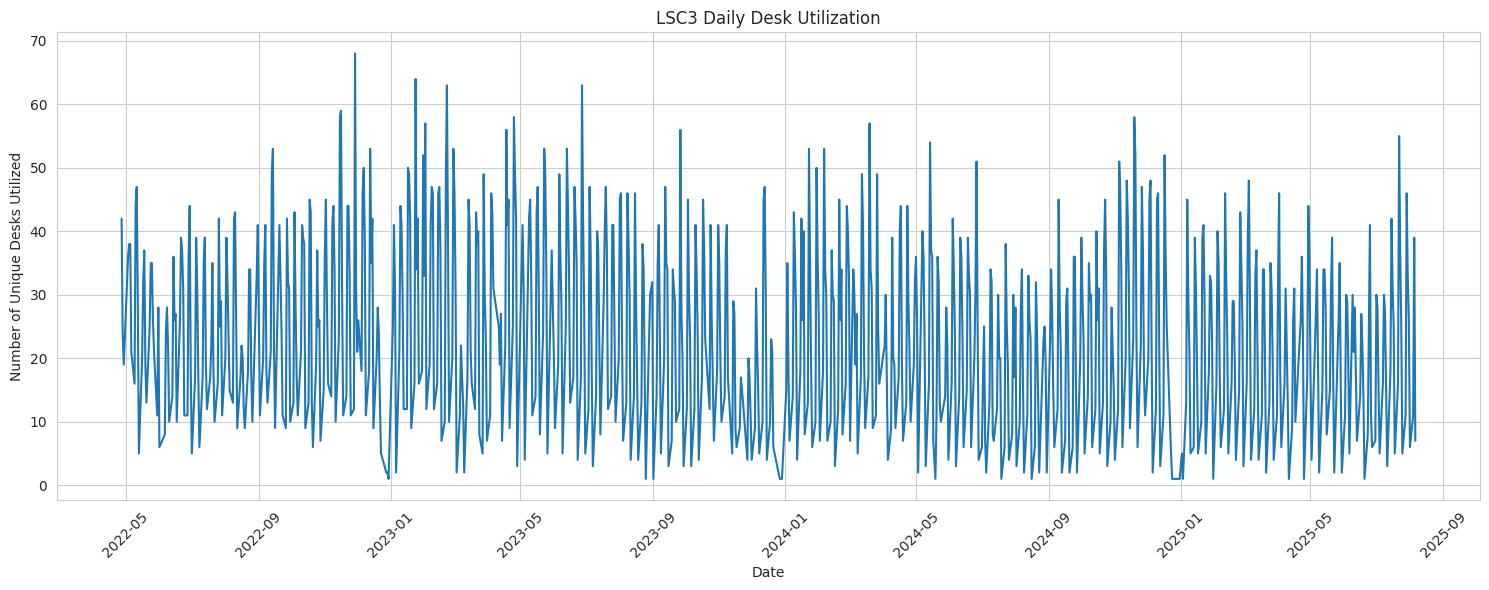

In [30]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_utilization, x="Date", y="UniqueDesksUtilized")
plt.title("LSC3 Daily Desk Utilization")
plt.xlabel("Date")
plt.ylabel("Number of Unique Desks Utilized")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("daily_utilization.png")
plt.show() # Display plot inline

# Plot Day of Week Utilization

/tmp/ipython-input-455513117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_of_week_utilization, x="DayOfWeek", y="UniqueDesksUtilized", palette="viridis")


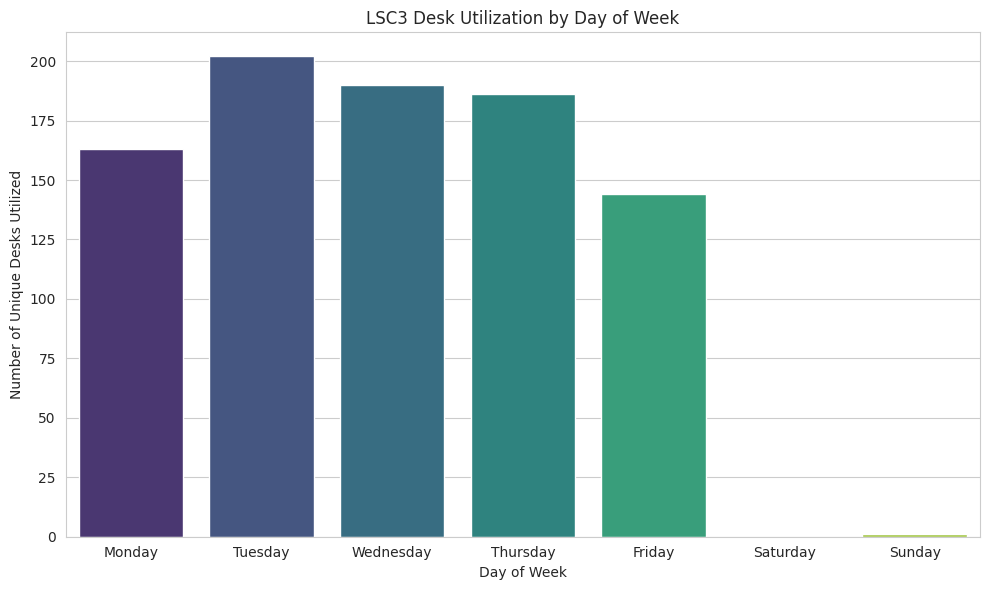

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=day_of_week_utilization, x="DayOfWeek", y="UniqueDesksUtilized", palette="viridis")
plt.title("LSC3 Desk Utilization by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Unique Desks Utilized")
plt.tight_layout()
plt.savefig("day_of_week_utilization.png")
plt.show() # Display plot inline

# Plot Month of Year Utilization

/tmp/ipython-input-2024094161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=month_of_year_utilization, x="Month", y="UniqueDesksUtilized", palette="magma")


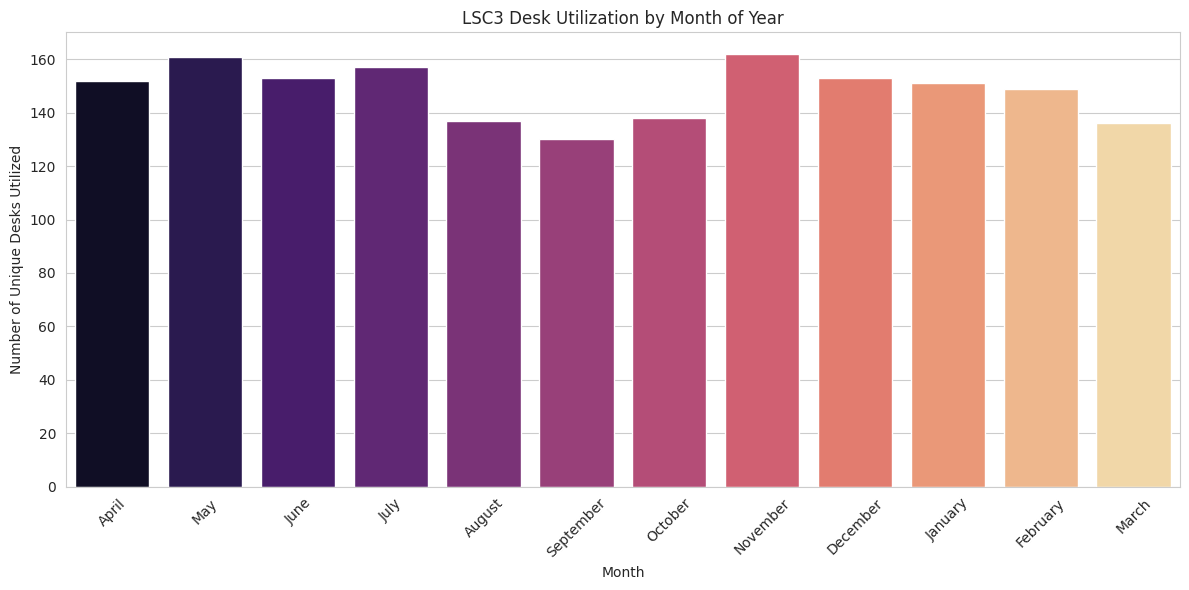

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=month_of_year_utilization, x="Month", y="UniqueDesksUtilized", palette="magma")
plt.title("LSC3 Desk Utilization by Month of Year")
plt.xlabel("Month")
plt.ylabel("Number of Unique Desks Utilized")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("month_of_year_utilization.png")
plt.show() # Display plot inline


# Plot Departmental Utilization

/tmp/ipython-input-2689123819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=department_utilization, x="UniqueDesksUtilized", y="Department", palette="cividis")


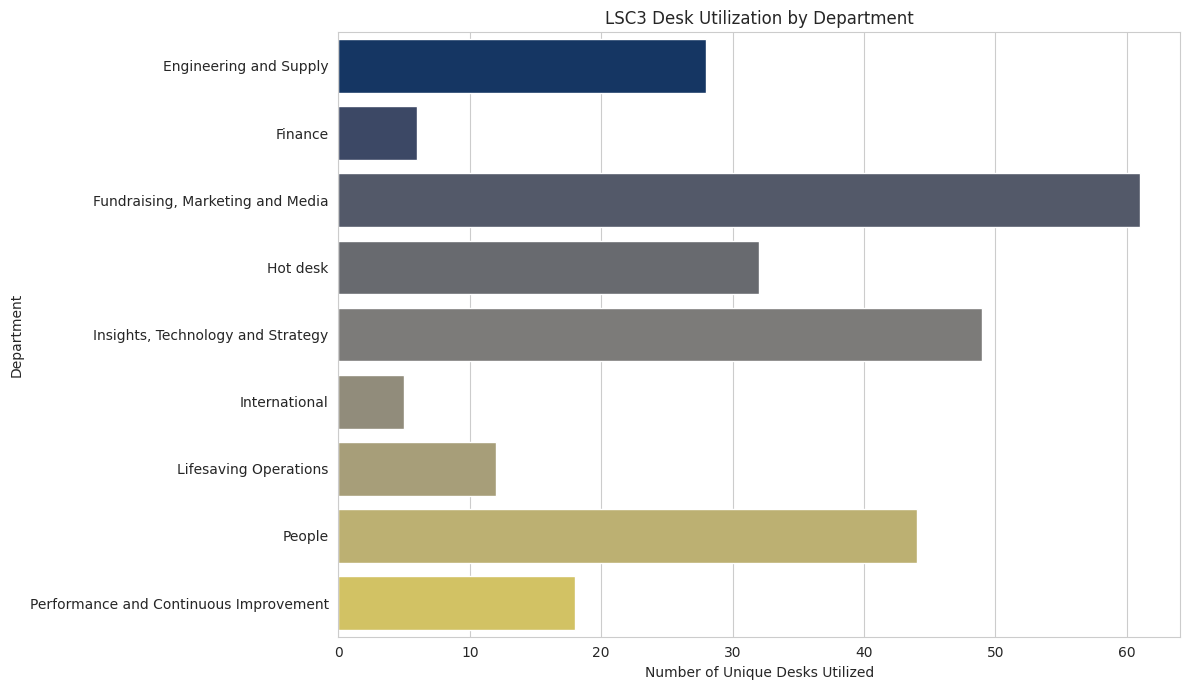

In [33]:
plt.figure(figsize=(12, 7))
sns.barplot(data=department_utilization, x="UniqueDesksUtilized", y="Department", palette="cividis")
plt.title("LSC3 Desk Utilization by Department")
plt.xlabel("Number of Unique Desks Utilized")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig("departmental_utilization.png")
plt.show() # Display plot inline

# Plot Accessibility Utilization

/tmp/ipython-input-3230668076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=accessibility_utilization, x="Accessibility", y="UniqueDesksUtilized", palette="plasma")


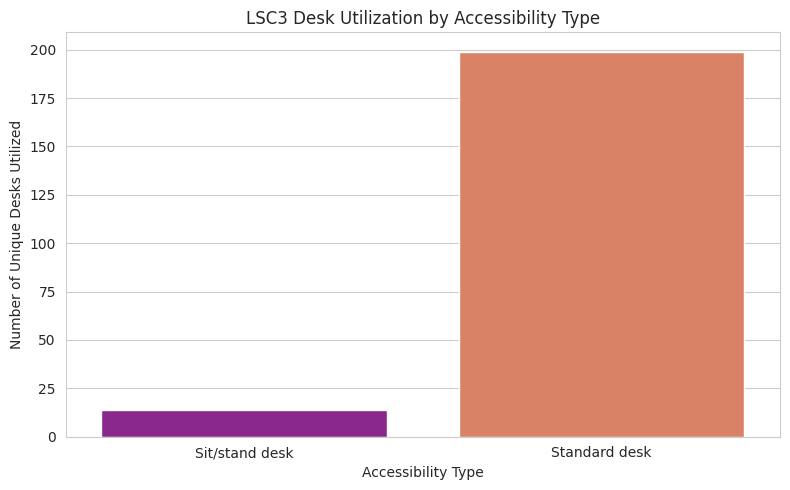

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=accessibility_utilization, x="Accessibility", y="UniqueDesksUtilized", palette="plasma")
plt.title("LSC3 Desk Utilization by Accessibility Type")
plt.xlabel("Accessibility Type")
plt.ylabel("Number of Unique Desks Utilized")
plt.tight_layout()
plt.savefig("accessibility_utilization.png")
plt.show() # Display plot inline

#Perform Predictive Modeling

# Prepare data for Prophet

In [36]:
daily_utilization_prophet = daily_utilization.rename(columns={"Date": "ds", "UniqueDesksUtilized": "y"})

# Initialize and fit the Prophet model

In [37]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False, # Daily seasonality might be captured by weekly
    seasonality_mode='additive'
)
model.fit(daily_utilization_prophet)

DEBUG:cmdstanpy:input tempfile: /tmp/tmprliv34s4/qndgo8wh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprliv34s4/nyffq073.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=2510', 'data', 'file=/tmp/tmprliv34s4/qndgo8wh.json', 'init=/tmp/tmprliv34s4/nyffq073.json', 'output', 'file=/tmp/tmprliv34s4/prophet_model_2oykjxu/prophet_model-20251003121112.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:11:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:11:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


# Create a future dataframe for predictions (e.g., next 365 days)

In [38]:
future = model.make_future_dataframe(periods=365)

# Make predictions

In [39]:
forecast = model.predict(future)

# Display the forecast (first few rows)

In [40]:
print("\n--- Forecast Data (Head) ---")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head())


--- Forecast Data (Head) ---
          ds       yhat  yhat_lower  yhat_upper
0 2022-04-27  38.768832   28.946672   47.948989
1 2022-04-28  28.811414   19.773987   37.947065
2 2022-04-29  11.862724    2.456717   20.618004
3 2022-05-03  45.188051   34.509371   54.535725
4 2022-05-04  41.062718   31.819747   50.221245


# Plot the forecast

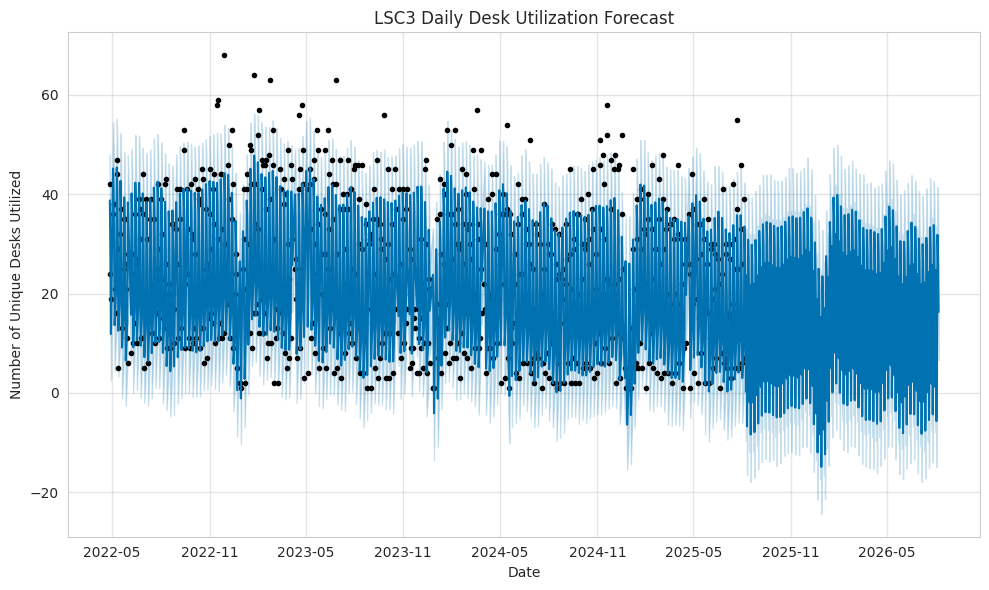

In [41]:
fig1 = model.plot(forecast)
plt.title("LSC3 Daily Desk Utilization Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Unique Desks Utilized")
plt.tight_layout()
plt.savefig("lsc3_utilization_forecast.png")
plt.show()

# Plot the forecast components

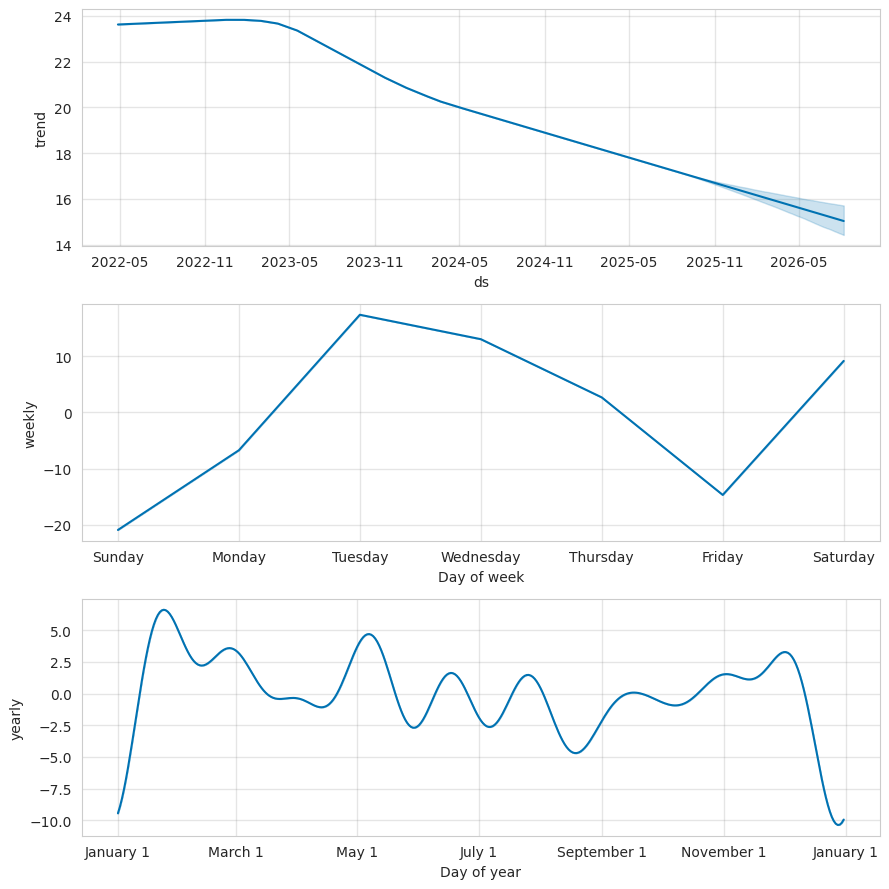

In [42]:
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig("lsc3_utilization_forecast_components.png")
plt.show()

# Save forecast data to CSV

In [43]:
forecast.to_csv("lsc3_utilization_forecast_data.csv", index=False)

In [44]:
print("\nPredictive modeling complete. Forecast plots and data saved.")


Predictive modeling complete. Forecast plots and data saved.
